# How to create a texture property

This tutorial demonstrates how to create a texture property.
## What is a textur property?
A texture property (also named material), gathers 3 notions:
the surface optical property (SOP), the texture and the volume optical property (VOP).
The property is then applied to a geometry (like bodies, faces).

## Prerequisites

### Perform imports

In [1]:
import os
from pathlib import Path

from ansys.speos.core import Face, Project, Speos, launcher
from ansys.speos.core.generic.parameters import MeshData
from ansys.speos.core.generic.version_checker import server_version_checker
from ansys.speos.core.kernel.client import (
    default_docker_channel,
)
from ansys.speos.core.sensor import SensorRadiance
from ansys.speos.core.simulation import SimulationInverse
from ansys.speos.core.source import SourceAmbientEnvironment


### Define constants

 help ensure consistency and avoid repetition throughout the example.

In [2]:
HOSTNAME = "localhost"
GRPC_PORT = 50098  # Be sure the Speos GRPC Server has been started on this port.
USE_DOCKER = True  # Set to False if you're running this example locally as a Notebook.

## Define helper functions

In [3]:
def create_helper_geometries(project: Project):
    """Create bodies and faces."""

    def create_rect_face(my_body, name, pos, x, y) -> Face:
        face = my_body.create_face(name=name)
        face.vertices = [
            pos[0],
            pos[1],
            pos[2],
            pos[0],
            pos[1] + y,
            pos[2],
            pos[0] + x,
            pos[1],
            pos[2],
            pos[0] + x,
            pos[1] + y,
            pos[2],
        ]
        face.facets = [0, 1, 2, 1, 2, 3]
        face.normals = [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0]
        return face

    root_part = project.create_root_part()
    data = {"bodies": [], "faces": [], "rp": root_part}
    data["bodies"].append(root_part.create_body(name="TheBody0"))
    data["bodies"].append(root_part.create_body(name="TheBody1"))
    data["bodies"].append(root_part.create_body(name="TheBody2"))
    data["bodies"].append(root_part.create_body(name="TheBody3"))
    data["bodies"].append(root_part.create_body(name="TheBody4"))
    data["bodies"].append(root_part.create_body(name="TheBody5"))
    data["faces"].append(create_rect_face(data["bodies"][0], "face0_0", [0, 0, 0], 5, 5))
    data["faces"].append(create_rect_face(data["bodies"][1], "Face1_0", [6, 0, 0], 5, 10))
    data["faces"].append(create_rect_face(data["bodies"][2], "Face2_0", [12, 0, 0], 10, 5))
    data["faces"].append(create_rect_face(data["bodies"][3], "Face3_0", [0, -6, 0], 5, 5))
    data["faces"].append(create_rect_face(data["bodies"][4], "Face4_0", [6, -6, 0], 5, 5))
    data["faces"].append(create_rect_face(data["bodies"][5], "Face5_0", [12, -6, 0], 5, 5))
    root_part.commit()
    return data

## Model Setup

### Load assets
The assets used to run this example are available in the
[PySpeos repository](https://github.com/ansys/pyspeos/) on GitHub.

> **Note:** Make sure you
> have downloaded simulation assets and set ``assets_data_path``
> to point to the assets folder.

In [4]:
if USE_DOCKER:  # Running on the remote server.
    assets_data_path = Path("/app") / "assets"
else:
    assets_data_path = Path("/path/to/your/download/assets/directory")

## Connect to the RPC Server
This Python client connects to a server where the Speos engine
is running as a service. In this example, the server and
client are the same machine. The launch_local_speos_rpc_method can
be used to start a local instance of the service.

In [5]:
if USE_DOCKER:
    speos = Speos(channel=default_docker_channel(port=GRPC_PORT))
else:
    speos = launcher.launch_local_speos_rpc_server(port=GRPC_PORT)

/home/runner/work/pyspeos/pyspeos/.venv/lib/python3.14/site-packages/ansys/tools/common/cyberchannel.py:201: UserWarning: Starting gRPC client without TLS on localhost:50098. This is INSECURE. Consider using a secure connection.
  warn(f"Starting gRPC client without TLS on {target}. This is INSECURE. Consider using a secure connection.")


### Create a new project

The only way to create an optical property using the core layer, is to create it from a project.
The ``Project`` class is instantiated by passing a ``Speos`` instance

In [6]:
p = Project(speos=speos)
print(p)

{
    "name": "",
    "description": "",
    "metadata": {},
    "part_guid": "",
    "sub_scene_anchor_axis_system": [],
    "sources": [],
    "sensors": [],
    "simulations": [],
    "materials": [],
    "scenes": []
}


## Add geometries

we use the helper function to create a variety of rectangular geometries to allow the application
of textures

/home/runner/work/pyspeos/pyspeos/.venv/lib/python3.14/site-packages/ansys/tools/visualization_interface/backends/pyvista/pyvista_interface.py:479: UserWarning: Failed to use notebook backend "html": Please install `ipywidgets`.

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"
  self.scene.show(jupyter_backend=jupyter_backend, **kwargs)


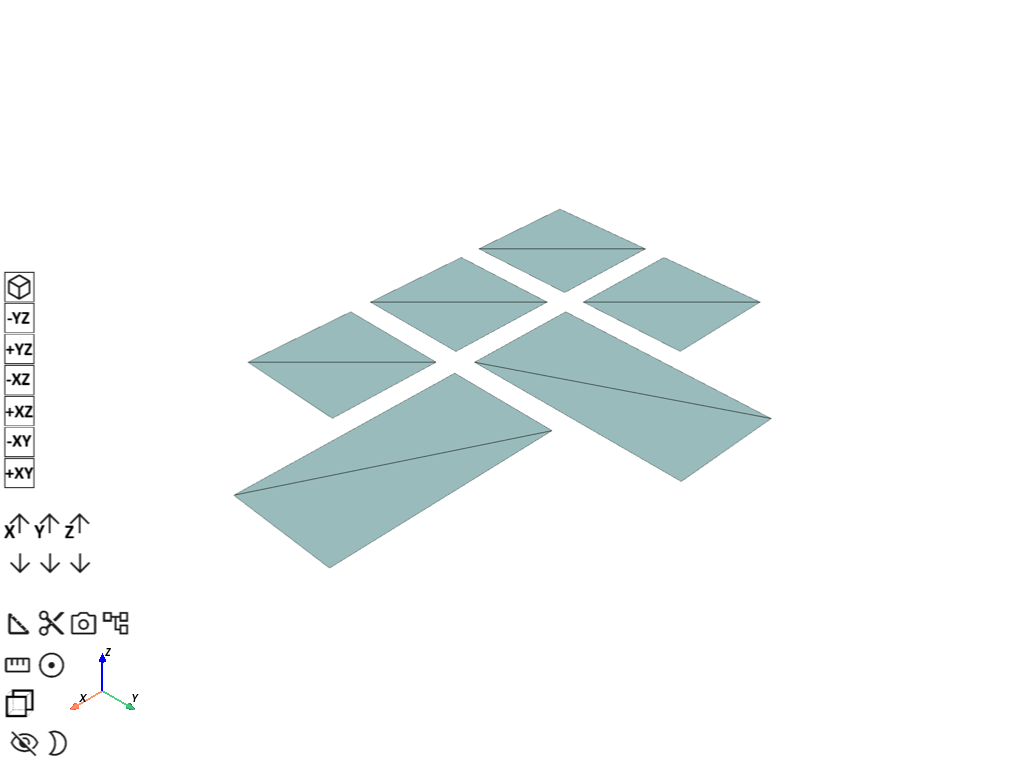

In [7]:
data = create_helper_geometries(p)
bodies = data["bodies"]
faces = data["faces"]
p.preview()

## Create Ambient source

In [8]:
src = p.create_source(name="Ambient", feature_type=SourceAmbientEnvironment)
src.luminance = 1000
src.image_file_uri = Path(assets_data_path) / "uffizi_cross.hdr"
src.set_predefined_color_space().set_color_space_srgb()
src.zenith_direction = [0.0, 0.0, 1.0]
src.north_direction = [1.0, 0.0, 0.0]
src.commit()

## Create Radiance Sensor

In [9]:
ssr = p.create_sensor(name="Radiance", feature_type=SensorRadiance)
ssr.axis_system = [11, 0, 10, 1, 0, 0, 0, 1, 0, 0, 0, 1]
ssr.integration_angle = 5
ssr.dimensions.x_start = -8
ssr.dimensions.x_end = 8
ssr.dimensions.x_sampling = 200
ssr.dimensions.y_start = -8
ssr.dimensions.y_end = 8
ssr.dimensions.y_sampling = 200
ssr.focal = 10
wv = ssr.set_type_spectral().set_wavelengths_range()
wv.start = 400
wv.end = 800
wv.sampling = 13
ssr.commit()

## Create Inverse Simulation with define Texture normalization

In [10]:
sim = p.create_simulation(name="Inverse", feature_type=SimulationInverse)
sim.sensor_paths = ["Radiance"]
sim.source_paths = ["Ambient"]
sim.set_texture_normalization_none()
sim.commit()

## Preview the project setup

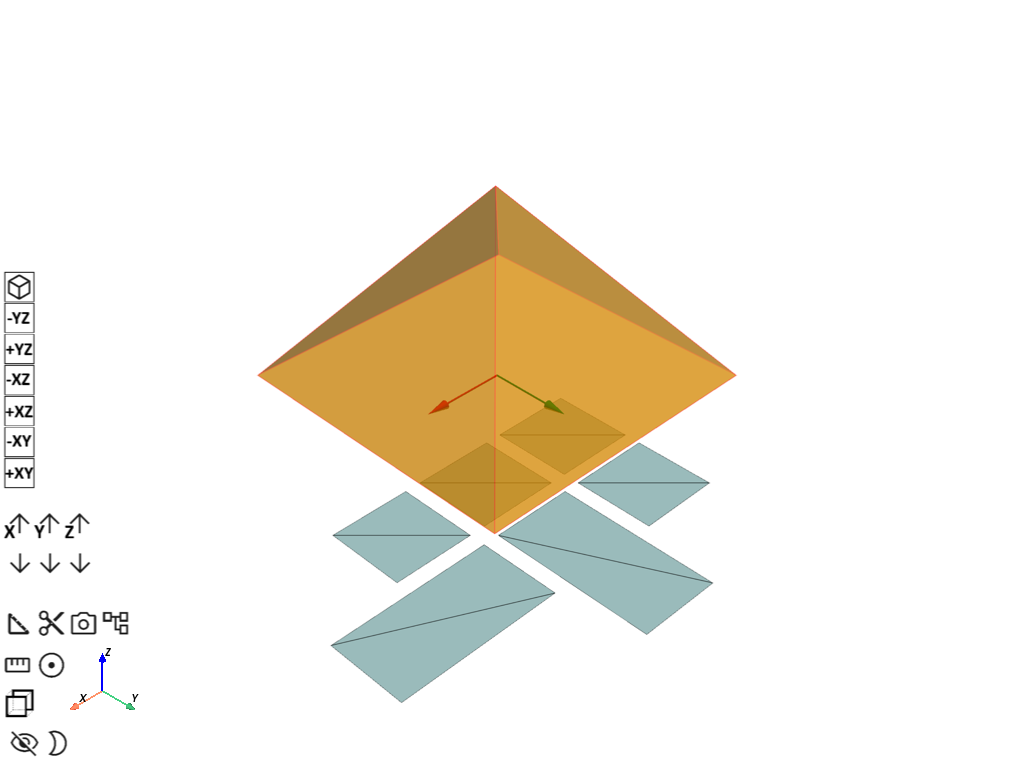

In [11]:
p.preview()

### Create Texture Properties via UV Mapping

# Activate texture settings inside optical property
Here we create a default optical property for the planner square shape surface
The dimension of surface is 5 x 5.

In [12]:
opt = p.create_optical_property(name="optical_property")
opt.set_volume_none()
opt.set_surface_mirror().reflectance = 0
opt.geometries = [faces[0]]
opt.commit()
print(opt)

{
    "name": "optical_property",
    "metadata": {
        "UniqueId": "8975d7aa-f7bf-4923-bd42-03d8c837e85d"
    },
    "geometries": {
        "geo_paths": [
            "TheBody0/face0_0"
        ]
    },
    "sop_guid": "72c3e717-b203-488b-88a5-b930f7156c26",
    "display_name": "",
    "description": "",
    "sop_guids": [],
    "sop": {
        "name": "optical_property.SOP",
        "mirror": {
            "reflectance": 0.0
        },
        "description": "",
        "metadata": {}
    },
    "sops": [
        {
            "name": "optical_property.SOP",
            "mirror": {
                "reflectance": 0.0
            },
            "description": "",
            "metadata": {}
        }
    ]
}


## Run Simulation and open result
Image result shows black surface as mirror reflectance is 0.

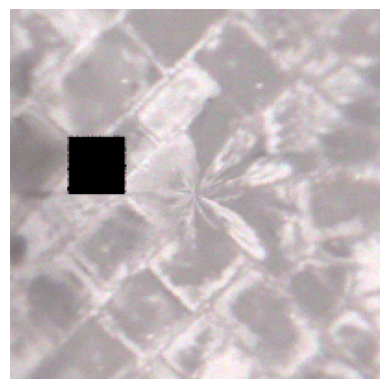

In [13]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

Here we activate the texture and create the first texture layer
By default, each texture layer is set as mirror with 100% reflectance.
No mapping method has been defined yet.
No image texture and normal map are applied.

In [14]:
texture_layer_1 = opt.create_texture_layer()
opt.commit()
print(len(opt.texture))
print(opt)

1
{
    "name": "optical_property",
    "metadata": {
        "UniqueId": "8975d7aa-f7bf-4923-bd42-03d8c837e85d"
    },
    "geometries": {
        "geo_paths": [
            "TheBody0/face0_0"
        ]
    },
    "texture": {
        "layers": [
            {
                "sop_guid": "8ddec20a-e95b-4006-8319-9585d2d42672",
                "sop": {
                    "name": "Layer0.SOP",
                    "mirror": {
                        "reflectance": 100.0
                    },
                    "description": "",
                    "metadata": {}
                }
            }
        ]
    },
    "display_name": "",
    "description": "",
    "sop_guids": [],
    "sops": [
        {
            "name": "optical_property.SOP",
            "mirror": {
                "reflectance": 0.0
            },
            "description": "",
            "metadata": {}
        }
    ]
}


Run simulation and result shows mirror surface as the default texture layer
Image result shows mirror surface as mirror reflectance is 100.

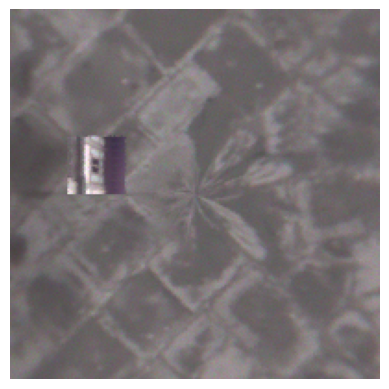

In [15]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

Here we the second texture layer
This is additional texture layer stack on top of the first texture layer.
the texture layer order is following the order of creation.
Similarly, texture layer is set as mirror without image and normal map.

In [16]:
texture_layer_2 = opt.create_texture_layer()
opt.commit()
print(len(opt.texture))
print(opt)

2
{
    "name": "optical_property",
    "metadata": {
        "UniqueId": "8975d7aa-f7bf-4923-bd42-03d8c837e85d"
    },
    "geometries": {
        "geo_paths": [
            "TheBody0/face0_0"
        ]
    },
    "texture": {
        "layers": [
            {
                "sop_guid": "8ddec20a-e95b-4006-8319-9585d2d42672",
                "sop": {
                    "name": "Layer0.SOP",
                    "mirror": {
                        "reflectance": 100.0
                    },
                    "description": "",
                    "metadata": {}
                }
            },
            {
                "sop_guid": "8ebbfa04-8041-467b-a4b2-b84fbc9d7735",
                "sop": {
                    "name": "Layer1.SOP",
                    "mirror": {
                        "reflectance": 100.0
                    },
                    "description": "",
                    "metadata": {}
                }
            }
        ]
    },
    "display_name": "",


Here we can delete 1 layer, e.g. the first layer

In [17]:
texture_layer_1.delete()
opt.commit()
print(len(opt.texture))  # only has 1 texture layer left
print(opt)

1
{
    "name": "optical_property",
    "metadata": {
        "UniqueId": "8975d7aa-f7bf-4923-bd42-03d8c837e85d"
    },
    "geometries": {
        "geo_paths": [
            "TheBody0/face0_0"
        ]
    },
    "texture": {
        "layers": [
            {
                "sop_guid": "8ebbfa04-8041-467b-a4b2-b84fbc9d7735",
                "sop": {
                    "name": "Layer1.SOP",
                    "mirror": {
                        "reflectance": 100.0
                    },
                    "description": "",
                    "metadata": {}
                }
            }
        ]
    },
    "display_name": "",
    "description": "",
    "sop_guids": [],
    "sops": [
        {
            "name": "optical_property.SOP",
            "mirror": {
                "reflectance": 0.0
            },
            "description": "",
            "metadata": {}
        }
    ]
}


User can NOT delete the last layer as this is last layer.
The following lines demon the error message.

In [18]:
try:
    opt.texture[0].delete()
except Exception as e:
    print("This is the last texture layer, it can not be deleted: {}".format(e))

This is the last texture layer, it can not be deleted: Cannot delete last remaining layer.


User can still use the texture layer as SOP to apply surface
optical property as usual. Use image texture and normal map as None.

In [19]:
new_texture_layer = opt.create_texture_layer()
opt.texture[0].set_surface_library().file_uri = (
    Path(assets_data_path) / "Texture.1.speos" / "100% transparent.simplescattering"
)
opt.texture[0].set_image_texture_to_none()
opt.texture[0].set_normal_map_to_none()
opt.commit()

Run simulation and result shows a fully transparent surface as defined in
simplescattering file.

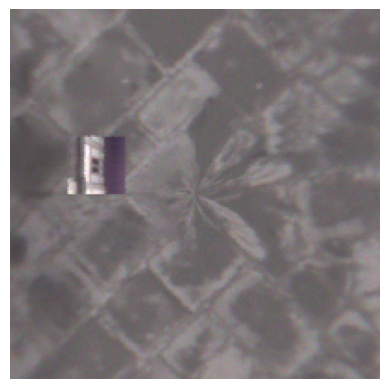

In [20]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

### Create Texture Properties via UV Mapping or MeshData

## Create Texture Property by UV Mapping
User can create some UV Mappings method as using:
planar, cubic, spherical or cylindrical UV mapping method.
Here, we create another texture layer.
With the previously remained texture layer, in total, there are 2 texture layers.

In [21]:
texture_layer_3 = opt.create_texture_layer()
texture_layer_3.set_surface_library().file_uri = Path(assets_data_path) / "L100 2.simplescattering"

UV mapping axis system will locate the center of the texture image,
in this example:
texture image center: x = 0, y = 0, z = 0
x-axis direction: vector = [0, 0, 1] is used for projection of the texture image.
y-axis direction: vector = [0, 1, 0] is used for top direction of the texture image.

Light will interact the last layer first.
texture image as checkerboard where alpha value is 0 for passing the ray toward the
subsequent layer -> fully transparent layer where alpha value is not 0 for interacting
with the L100 2.simplescattering material.

In [22]:
texture_layer_3.set_image_texture().set_uv_mapping_planar().axis_system = [
    0,
    0,
    0,
    0,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    0,
]
texture_layer_3.image_texture.image_file_uri = (
    Path(assets_data_path) / "Texture.1.speos" / "white_trans_checkerboard.png"
)
texture_layer_3.image_texture.repeat_v = False
texture_layer_3.image_texture.repeat_u = False
texture_layer_3.image_texture.uv_mapping.u_length = 2.5
texture_layer_3.image_texture.uv_mapping.v_length = 2.5
texture_layer_3.set_normal_map_to_none()
opt.commit()

Run simulation and result shows white in the checkerboard area while
transparent at the other area.

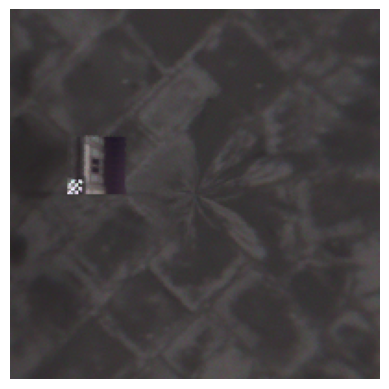

In [23]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

Move the texture image up in the y direction and run result.
The new center of texture image is [0, 2.5, 0]

In [24]:
texture_layer_3.image_texture.uv_mapping.axis_system = [0, 2.5, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0]
opt.commit()

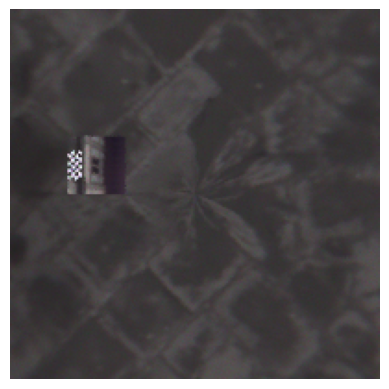

In [25]:
results = sim.compute_CPU()  # use GPU using "compute_GPU" method
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

Run simulation and result pattern will be repeated.

In [26]:
texture_layer_3.image_texture.repeat_v = True
texture_layer_3.image_texture.repeat_u = True
opt.commit()

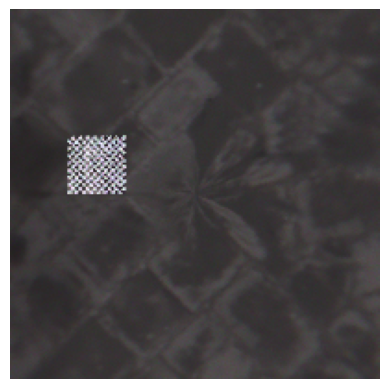

In [27]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

Run simulation and result pattern will be enlarged.

In [28]:
texture_layer_3.image_texture.uv_mapping.u_length = 10
texture_layer_3.image_texture.uv_mapping.v_length = 10
opt.commit()

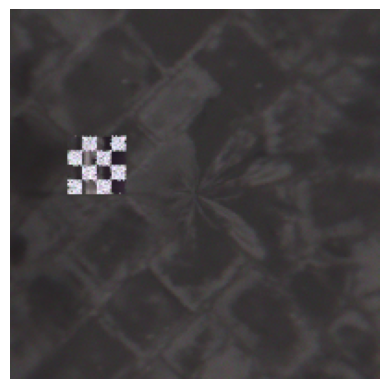

In [29]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

## Create Texture Property by data
When texture is create by data the image gets positioned on the geometry using
the uv information stored in the mesh vertices data attribute on the face.

## Apply vertices data for all faces except the first

we create image locations for each vertex and provide these to each face to position the texture
on the Geometry. we give for each vertex the u,v location of the image
data structure for the MeshData:
Texture coordinates uv: (u1 v1 u2 v2 ...) with u1 and v1 the coordinates for the first vertex.
Typically ranging from 0.0 to 1.0, where (0.0 0.0) is the bottom-left and (1.0 1.0) is the
top-right of the texture.
In this section we create different mappings by playing with the u value assigned to the vertices.
The V value is kept unchanged for all faces as we use a picture which has stripes along the v
direction and playing with v would induce no change in the result.

In [30]:
face1_0 = faces[1]  # vertical rectangular with base as 5 and height as 10.
# face1_0 is made of 4 vertices:
# 1st vertice at location (6, 0, 0)
# 2nd vertice at location (6, 10, 0)
# 3rd vertice at location (11, 0, 0)
# 4th vertice at location (6, 10, 0)
face1_0.vertices_data = [
    MeshData(
        name="uv_0",
        data=[
            0.0,
            1.0,  # 1st vertice at (6, 0, 0) => texture image (0, 1) top left corner
            0.0,
            0.0,  # 2nd vertice at (6, 10, 0) => texture image (0, 0) button left corner
            1.0,
            1.0,  # 3rd vertice at (11, 0, 0) => texture image (1, 1) top right corner
            1.0,
            0.0,  # 4th vertice at (6, 10, 0) => texture image (0, 0) button right corner
        ],
    )  # full picture
]
data["rp"].commit()
print(face1_0)

{
    "name": "Face1_0",
    "vertices": [
        6.0,
        0.0,
        0.0,
        6.0,
        10.0,
        0.0,
        11.0,
        0.0,
        0.0,
        11.0,
        10.0,
        0.0
    ],
    "facets": [
        0,
        1,
        2,
        1,
        2,
        3
    ],
    "normals": [
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0
    ],
    "vertices_data": [
        {
            "name": "uv_0",
            "data": [
                0.0,
                1.0,
                0.0,
                0.0,
                1.0,
                1.0,
                1.0,
                0.0
            ]
        }
    ],
    "display_name": "",
    "description": "",
    "metadata": {},
    "facets_data": []
}


In [31]:
opt_2 = p.create_optical_property(name="optical_property.2")
opt_2.set_volume_none()
opt_2.geometries = [
    face1_0.geo_path,
]

In [32]:
opt_2_layer_1 = opt_2.create_texture_layer()
opt_2_layer_1.set_surface_library().file_uri = Path(assets_data_path) / "L100 2.simplescattering"
opt_2_layer_1.set_image_texture().image_file_uri = (
    Path(assets_data_path) / "Texture.1.speos" / "textureColors_half.jpg"
)
opt_2_layer_1.image_texture.set_uv_mapping_by_data()

Select which meshdata assign to the face is used to position the image on the geometry.
Here we have only created one meshdata with uv coordinates but if there were several
you could select which one to use for the mapping

In [33]:
opt_2_layer_1.image_texture.uv_mapping.vertices_data_index = 0
opt_2_layer_1.image_texture.repeat_u = False
opt_2_layer_1.image_texture.repeat_v = False
opt_2.commit()

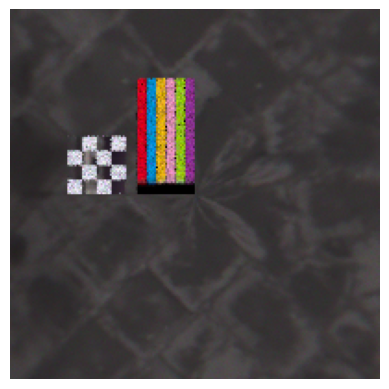

In [34]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

Modify the UV mapping MeshData, the following example flip the texture image upside-down.
Until 26R1 SP1 included, it is known behaviour that, previous vertices data will not
be removed, but just appending new MeshData.
This is corrected in the RPC version: 26R1 SP2.

In [35]:
uv_1 = MeshData(
    name="uv_1",
    data=[
        0.0,
        0.0,  # 1st vertice at (6, 0, 0) => texture image (0, 1) button left corner
        0.0,
        1.0,  # 2nd vertice at (6, 10, 0) => texture image (0, 0) top left corner
        1.0,
        0.0,  # 3rd vertice at (11, 0, 0) => texture image (1, 1) button right corner
        1.0,
        1.0,  # 4th vertice at (6, 10, 0) => texture image (0, 0) top right corner
    ],
)  # full picture

In [36]:
if server_version_checker.is_version_supported(2026, 1, 2):
    face1_0.vertices_data = face1_0.vertices_data + [uv_1]
else:
    face1_0.vertices_data = [uv_1]
data["rp"].commit()
print(face1_0)

{
    "name": "Face1_0",
    "vertices": [
        6.0,
        0.0,
        0.0,
        6.0,
        10.0,
        0.0,
        11.0,
        0.0,
        0.0,
        11.0,
        10.0,
        0.0
    ],
    "facets": [
        0,
        1,
        2,
        1,
        2,
        3
    ],
    "normals": [
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0
    ],
    "vertices_data": [
        {
            "name": "uv_0",
            "data": [
                0.0,
                1.0,
                0.0,
                0.0,
                1.0,
                1.0,
                1.0,
                0.0
            ]
        },
        {
            "name": "uv_1",
            "data": [
                0.0,
                0.0,
                0.0,
                1.0,
                1.0,
                0.0,
                1.0,
                1.0
            ]
        

To use the new MeshData, user can choose the new MeshData by setting the index.
Here we set index to 1 to select the new MeshData we just created.

In [37]:
opt_2_layer_1.image_texture.uv_mapping.vertices_data_index = 1
opt_2.commit()

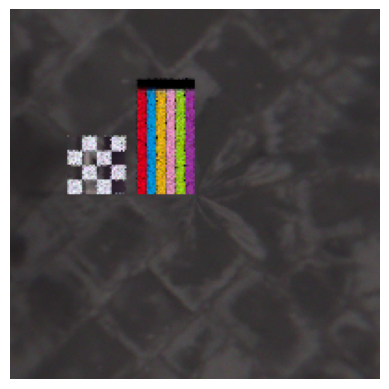

In [38]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

The following rotation the texture image by 90 degree.

In [39]:
uv_2 = MeshData(
    name="uv_2",
    data=[
        0.0,
        1.0,  # 1st vertice at (6, 0, 0) => texture image (0, 1) button left corner
        1.0,
        1.0,  # 2nd vertice at (6, 10, 0) => texture image (0, 0) top left corner
        0.0,
        0.0,  # 3rd vertice at (11, 0, 0) => texture image (1, 1) button right corner
        1.0,
        0.0,  # 4th vertice at (6, 10, 0) => texture image (0, 0) top right corner
    ],
)  # full picture
if server_version_checker.is_version_supported(2026, 1, 2):
    face1_0.vertices_data = face1_0.vertices_data + [uv_2]
else:
    face1_0.vertices_data = [uv_2]
data["rp"].commit()
print(face1_0)

{
    "name": "Face1_0",
    "vertices": [
        6.0,
        0.0,
        0.0,
        6.0,
        10.0,
        0.0,
        11.0,
        0.0,
        0.0,
        11.0,
        10.0,
        0.0
    ],
    "facets": [
        0,
        1,
        2,
        1,
        2,
        3
    ],
    "normals": [
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        1.0
    ],
    "vertices_data": [
        {
            "name": "uv_0",
            "data": [
                0.0,
                1.0,
                0.0,
                0.0,
                1.0,
                1.0,
                1.0,
                0.0
            ]
        },
        {
            "name": "uv_1",
            "data": [
                0.0,
                0.0,
                0.0,
                1.0,
                1.0,
                0.0,
                1.0,
                1.0
            ]
        

To use the new MeshData, user can choose the new MeshData by setting the index.
Here we set index to 2 to select the new MeshData we just created.

In [40]:
opt_2_layer_1.image_texture.uv_mapping.vertices_data_index = 2
opt_2.commit()

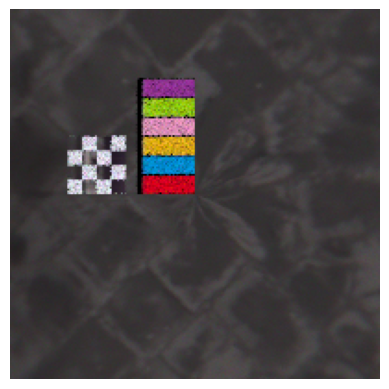

In [41]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")

The following examples shows using partial texture image, e.g. half or quarter.

In [42]:
face2_0 = faces[2]  # horizontal rectangular with base as 10 and height as 5.
# 1st vertice at location (12, 0, 0)
# 2nd vertice at location (12, 5, 0)
# 3rd vertice at location (22, 0, 0)
# 4th vertice at location (22, 5, 0)
face2_0.vertices_data = [
    MeshData(
        name="uv_0",
        data=[
            0.0,
            1.0,  # 1st vertice / Left bottom corner mesh -> left top corner of texture image
            0.0,
            0.0,  # 2nd vertice / Left top corner mesh -> left bottom corner of texture image
            1.0,
            1.0,  # 3rd vertice / Right bottom corner mesh -> right top corner of texture image
            1.0,
            0.0,  # 4th vertice / Right top corner mesh -> right bottom corner of texture image
        ],
    )  # full picture
]

Here we play with the u: from 0.0 to 0.5
first half of the texture image (half image in the left) is projected to the square surface.
i.e. red, blue, yellow

In [43]:
face3_0 = faces[3]  # square with dimension 5 by 5.
face3_0.vertices_data = [
    MeshData(
        name="uv_0",
        data=[
            0.0,
            1.0,  # 1st vertice / Left bottom corner mesh -> left top corner of texture image
            0.0,
            0.0,  # 2nd vertice / Left top corner mesh -> left bottom corner of texture image
            0.5,
            1.0,  # 3rd vertice / Right bottom corner mesh -> middle top corner of texture image
            0.5,
            0.0,  # 4th vertice / Right top corner mesh -> middle bottom corner of texture image
        ],
    )
]

Here we play with the u: from 0.5 to 1.0
second half of the image (half image in the right) is projected to the square surface
i.e. pink, green, purple

In [44]:
face4_0 = faces[4]
face4_0.vertices_data = [
    MeshData(
        name="uv_0",
        data=[
            0.5,
            1.0,  # 1st vertice / Left bottom corner mesh -> middle top corner of texture image
            0.5,
            0.0,  # 2nd vertice / Left top corner mesh -> middle bottom corner of texture image
            1.0,
            1.0,  # 3rd vertice / Right bottom corner mesh -> Right top corner of texture image
            1.0,
            0.0,  # 4th vertice / Right top corner mesh -> Right bottom corner of texture image
        ],
    )
]

Here we play with the u: from 4/6 to 5/6
green only

In [45]:
face5_0 = faces[5]
face5_0.vertices_data = [
    MeshData(name="uv_0", data=[4 / 6, 1.0, 4 / 6, 0.0, 5 / 6, 1.0, 5 / 6, 0.0])
]
data["rp"].commit()

In [46]:
opt_3 = p.create_optical_property(name="optical_property.3")
opt_3.set_volume_none()
opt_3.geometries = [
    face2_0.geo_path,
    face3_0.geo_path,
    face4_0.geo_path,
    face5_0.geo_path,
]
opt_3.commit()

In [47]:
opt_3_layer_1 = opt_3.create_texture_layer()
opt_3_layer_1.set_surface_library().file_uri = Path(assets_data_path) / "L100 2.simplescattering"
opt_3_layer_1.set_image_texture().image_file_uri = Path(assets_data_path) / "textureColors.jpg"
opt_3_layer_1.image_texture.set_uv_mapping_by_data()

Select which MeshData assign to the face is used to position the image on the geometry.
Here we have only created one meshdata with uv coordinates but if there were several
you could select which one to use for the mapping

In [48]:
opt_3_layer_1.image_texture.uv_mapping.vertices_data_index = 0
opt_3_layer_1.image_texture.repeat_u = False
opt_3_layer_1.image_texture.repeat_v = False
opt_3.commit()

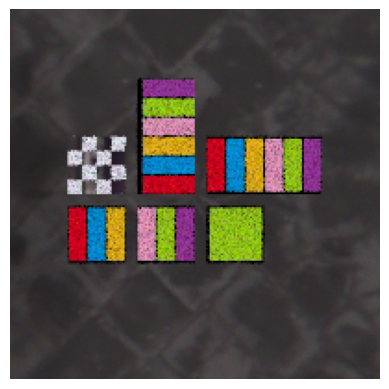

In [49]:
results = sim.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Radiance.xmp")